In [38]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import *
from sklearn.feature_extraction.text import CountVectorizer

In [39]:
df = pd.read_csv('IMDB_Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [40]:
df.shape

(50000, 2)

In [41]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [42]:
X = df['review']
y = df['sentiment']

# Convert text to numeric using CountVectorizer
vectorizer = CountVectorizer(stop_words='english', lowercase=True)
X = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
MNB = MultinomialNB()
MNB.fit(X_train, y_train)

y_pred = MNB.predict(X_test)

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8566
Confusion Matrix:
 [[4344  617]
 [ 817 4222]]
Classification Report:
               precision    recall  f1-score   support

    negative       0.84      0.88      0.86      4961
    positive       0.87      0.84      0.85      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



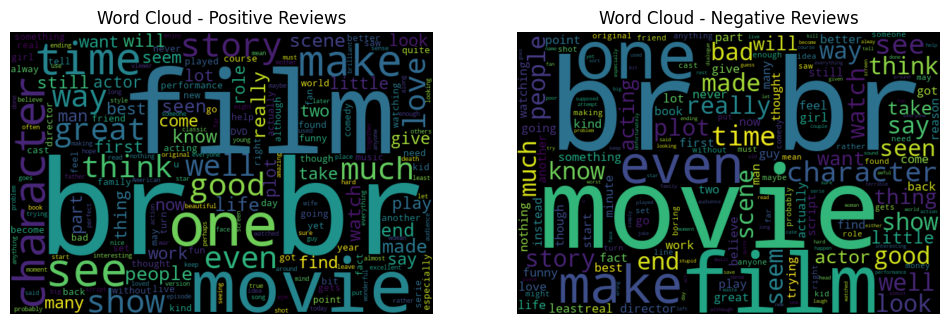

In [46]:
from wordcloud import WordCloud
# Both positive and negative reviews talk about similar things (movie, story, characters).
# The difference is:
# Positive reviews → praise (good, great, love)
# Negative reviews → criticism (bad, issues with plot/characters)
positive_reviews = ' '.join(df[df['sentiment']=='positive']['review'])
negative_reviews = ' '.join(df[df['sentiment']=='negative']['review'])

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
WordCloud(width=600,height=400, background_color='white').generate(positive_reviews)
plt.imshow(WordCloud(width=600,height=400).generate(positive_reviews), interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Reviews')

plt.subplot(1,2,2)
plt.imshow(WordCloud(width=600,height=400).generate(negative_reviews), interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Negative Reviews')
plt.show()

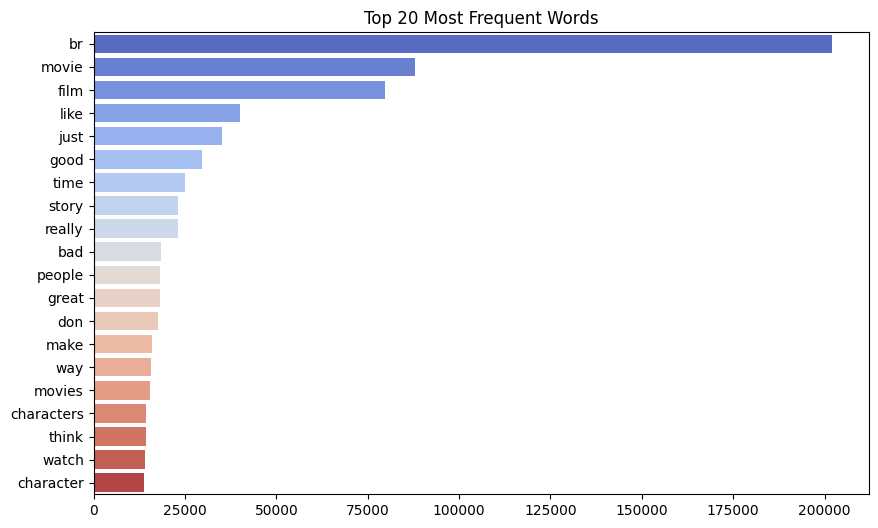

In [ ]:
from collections import Counter
import seaborn as sns

# Count top 20 words
vectorizer = CountVectorizer(stop_words='english')
X_words = vectorizer.fit_transform(df['review'])
word_counts = np.asarray(X_words.sum(axis=0)).flatten()
words = vectorizer.get_feature_names_out()
top_indices = word_counts.argsort()[-20:][::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=word_counts[top_indices], y=words[top_indices], hue=words[top_indices], palette='coolwarm', legend=False)
plt.title('Top 20 Most Frequent Words')
plt.show()

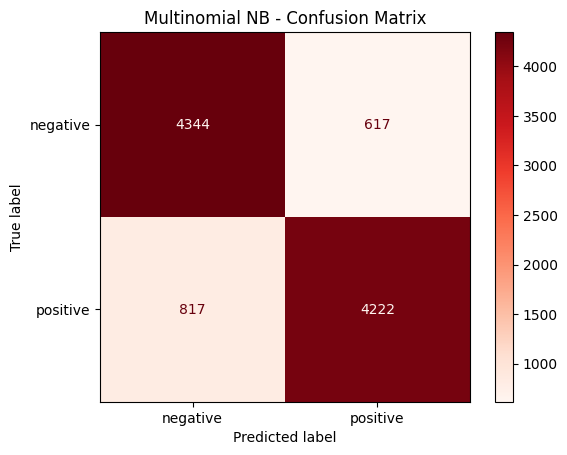

In [ ]:
ConfusionMatrixDisplay.from_estimator(MNB, X_test, y_test, cmap='Reds')
plt.title('Multinomial NB - Confusion Matrix')
plt.show()